In [5]:
LOGS_PATH = '../export/agent_logs'
EVAL_PATH = '../export/new_evaluation.json'

In [6]:
import os
import json
from collections import defaultdict
from json import JSONDecodeError
from collections import Counter


from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [7]:

to_do = []
for dirpath, _, filenames in os.walk(LOGS_PATH):
    for filename in filenames:
        if not filename.endswith('.json'):
            continue
        filepath = os.path.join(dirpath, filename)
        to_do.append((filepath, filename))

result = []
for filepath, filename in tqdm(to_do):
    try:
        with open(filepath, 'r') as file:
            log_content = json.load(file)
        stat_tools = defaultdict(lambda:0)
        fail_stat_tools = defaultdict(lambda:0)
        fail_messages = []
        proof_depth = len(log_content['blocks'])
        num_retry_cumulative = len(log_content['logs'])

        for block in log_content['blocks']:
            stat_tools[block['kind']] += 1
        for log in log_content['logs']:
            if 'content' in log and isinstance(log['content'], list):
                fail_stat_tools[log['content'][-1]['kind']] += 1
            if 'message' in log:
                fail_messages.append(log['message'])

        if 'message' in log_content:
            fail_messages.append(log_content['message'])
        result.append((log_content['status'], filename, dict(stat_tools), dict(fail_stat_tools), fail_messages, proof_depth, num_retry_cumulative))
    except JSONDecodeError:
        continue

100%|██████████| 289971/289971 [13:26<00:00, 359.41it/s]


In [8]:
count_thm = defaultdict(lambda:defaultdict(lambda:0))
all_fail = defaultdict(lambda:0)
tools_hist = defaultdict(lambda:[])
depth_hist = []

for status, filename, stat_tools, fail_stat, fail_messages, proof_depth, num_retry in result:
    subfilename = "_".join(filename.split("_")[1:-1])
    depth_hist.append(proof_depth)
    for key in fail_stat:
        all_fail[key] += fail_stat[key]
    for key in stat_tools:
        tools_hist[key].append(stat_tools[key])
    
    if status == 'success':
        count_thm[subfilename]['success'] += 1
    else:
        count_thm[subfilename]['fail'] += 1

for thm in count_thm:
    print(thm, dict(count_thm[thm]))


mathcomp.character.mxrepresentation.map_group_ring {'fail': 4478}
mathcomp.algebra.archimedean.Num.Theory.natrEint {'fail': 1733}
mathcomp.character.mxabelem.mx_Fp_stable {'fail': 7029}
mathcomp.field.fieldext.module_baseVspace {'fail': 2706}
mathcomp.algebra.poly.coef_prod_XsubC {'fail': 21086}
mathcomp.solvable.pgroup.bigcap_p'core {'fail': 2184}
mathcomp.solvable.extremal.Grp_ext_dihedral {'fail': 5483}
mathcomp.fingroup.action.morph_astab {'fail': 4661}
mathcomp.solvable.gseries.invariant_subnormal {'fail': 1855}
mathcomp.fingroup.morphism.morphim_norm {'fail': 2284, 'success': 8}
mathcomp.fingroup.morphism.sub_morphim_pre {'fail': 3488, 'success': 1}
mathcomp.algebra.matrix.mul_mx_adj {'fail': 2023}
mathcomp.algebra.poly.size_poly_prod_leq {'fail': 2425}
mathcomp.algebra.poly.size_comp_poly {'fail': 2549}
mathcomp.boot.prime.dvdn_partP {'fail': 2116}
mathcomp.field.fieldext.aspaceOverP {'fail': 4129}
mathcomp.field.algnum.num_field_proj {'fail': 894}
mathcomp.fingroup.gproduct.dpr

/tmp/ipykernel_158541/2412805360.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[idx].legend()


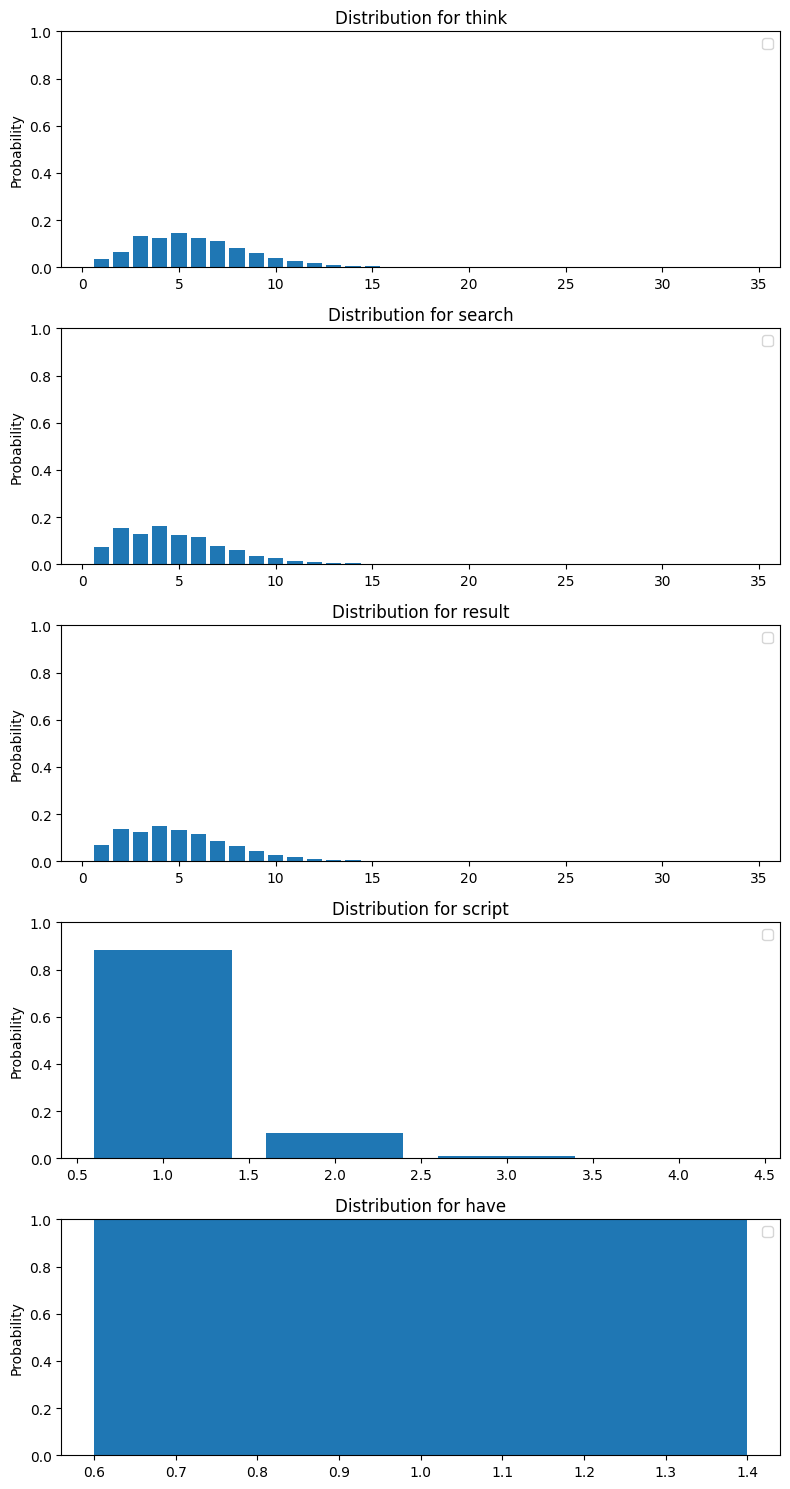

In [9]:
fig, axs = plt.subplots(len(tools_hist), 1, sharey=True, tight_layout=True, figsize=(8, 3 * len(tools_hist)))

for idx, key in enumerate(tools_hist):
    data = np.array(tools_hist[key])
    threshold = np.percentile(data, 99.9)
    data = data[data <= threshold]

    counts = Counter(data)
    total = sum(counts.values())
    probs = {k: v / total for k, v in counts.items()}

    axs[idx].bar(probs.keys(), probs.values(), width=0.8)
    axs[idx].set_ylim(0, 1.0)
    axs[idx].legend()
    axs[idx].set_ylabel("Probability")
    axs[idx].set_title(f"Distribution for {key}")

plt.show()

/tmp/ipykernel_158541/4163935322.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


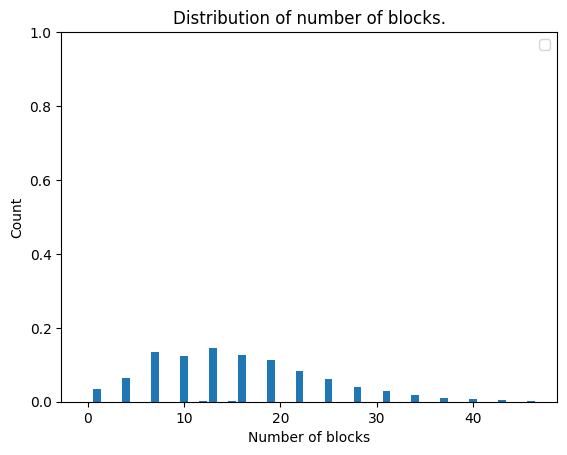

In [24]:
proof_depth = np.array([depth for _, _, _, _, _, depth, _ in result])
threshold = np.percentile(proof_depth, 99.)
proof_depth = proof_depth[proof_depth <= threshold]

counts = Counter(proof_depth)
total = sum(counts.values())
probs = {k: v / total for k, v in counts.items()}

plt.bar(probs.keys(), probs.values(), width=0.8)
plt.ylim(0, 1.0)
plt.ylabel("Count")
plt.xlabel("Number of blocks")
plt.title("Distribution of number of blocks.")
plt.legend()
plt.show()


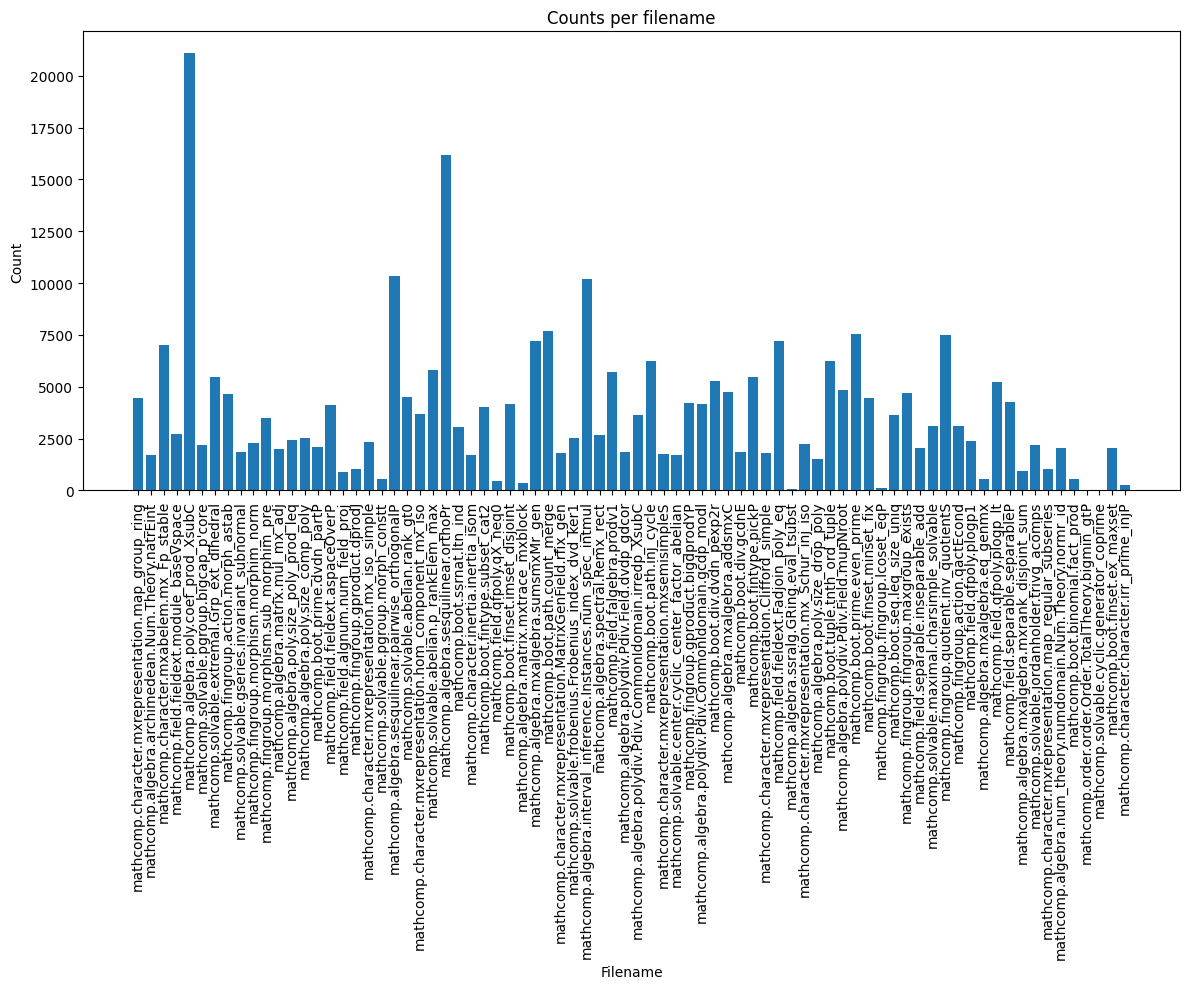

In [23]:
count = defaultdict(lambda:0)
for _, filename, _, _, _, _, _ in result:
    norm_filename = "_".join(filename.split('_')[1:-1])
    count[norm_filename] += 1

keys = list(count.keys())
values = list(count.values())

plt.figure(figsize=(12, 10))
plt.bar(keys, values)

plt.xticks(rotation=90)
plt.ylabel("Count")
plt.xlabel("Filename")
plt.title("Counts per filename")

plt.tight_layout()
plt.show()


100%|██████████| 289971/289971 [00:27<00:00, 10733.68it/s]


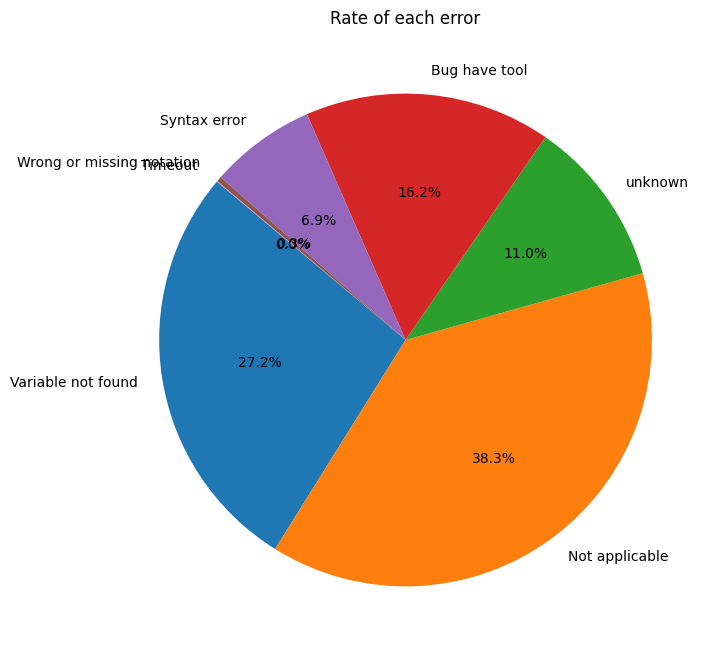

In [14]:
error_coq = {
    "Coq: Cannot apply": "Not applicable", #apply
    "Coq: Syntax Error": "Syntax error",
    "Coq: Tactic expected": "Syntax error",
    "Coq: Syntax error": "Syntax error",
    "does not match": "Not applicable",
    "not a rewritable relation": "Not applicable", # rewrite
    "Coq: No assumption in": "Not applicable",
    "Timeout": "Timeout",
    "Illegal application": "Not applicable",
    "Unable to unify": "Not applicable",
    "while it is expected to have type": "Not applicable",
    "Coq: Not an inductive": "Not applicable",
    "does not unify with": "Not applicable", # rewrite
    "Coq: No applicable tactic.": "Not applicable",
    "was not found in the current": "Variable not found",
    "'ScriptTool' object has no attribute 'goals'": "Bug have tool",
    "Unknown interpretation for notation": "Wrong or missing notation",
    "which should be Set, Prop or Type.": "Not applicable"
}

count = defaultdict(lambda:0)

for _, _, _, _, fail_messages, _, _ in tqdm(result):
    for message in fail_messages:
        found = False
        for error, cat in error_coq.items():
            if error in message:
                count[cat] += 1
                found = True
        if not found:
            count['unknown'] += 1

total = sum(count.values())
keys = list(count.keys())
values = [v / total for v in count.values()]  # normalize

plt.figure(figsize=(8, 8))
plt.pie(values, labels=keys, autopct="%1.1f%%", startangle=140)
plt.title("Rate of each error")
plt.show()

In [16]:
with open(EVAL_PATH, 'r') as file:
    eval = json.load(file)

eval_proof_lengths = []

dict_name_size = {}
for name, entry in eval.items():
    dict_name_size[name] = len(entry['evaluation'])
    eval_proof_lengths.append(len(entry['evaluation']))


/tmp/ipykernel_158541/3481293245.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


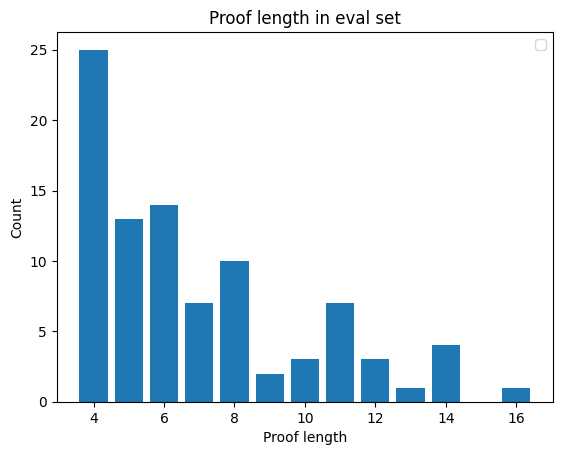

In [ ]:

counts = Counter(eval_proof_lengths)
plt.bar(counts.keys(), counts.values(), width=0.8)
plt.ylabel("Count")
plt.xlabel("Proof length")
plt.title("Proof Length in eval set")

plt.legend()
plt.show()

4 mathcomp.boot.fintype.subset_cat2
4 mathcomp.algebra.spectral.Remx_rect
7 mathcomp.fingroup.quotient.inv_quotientS
4 mathcomp.boot.tuple.tnth_ord_tuple
4 mathcomp.fingroup.morphism.morphim_norm
4 mathcomp.algebra.sesquilinear.orthoPr
5 mathcomp.fingroup.morphism.sub_morphim_pre


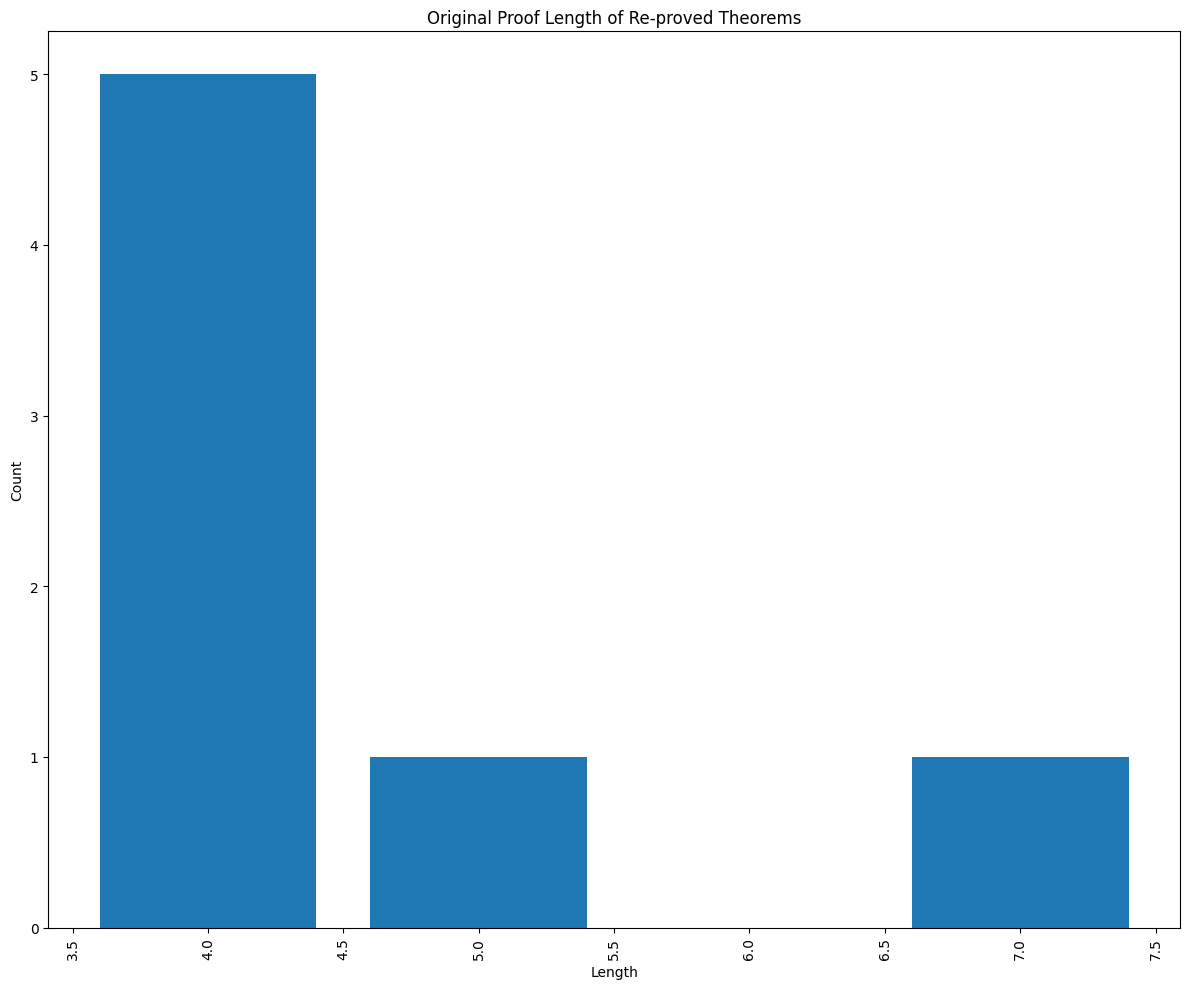

In [21]:
dict_size_success = defaultdict(lambda:0)
proved = set()
for _, filename, _, _, _, _, _ in result:
    norm_filename = "_".join(filename.split('_')[1:-1])
    if filename.startswith('SUCCESS'):
        proved.add(norm_filename)

for filename in proved:
    size = dict_name_size[filename]
    print(size, filename)
    dict_size_success[size] += 1

keys = list(dict_size_success.keys())
values = list(dict_size_success.values())

plt.figure(figsize=(12, 10))
plt.bar(keys, values)

plt.xticks(rotation=90)
plt.ylabel("Count")
plt.xlabel("Length")
plt.title("Original Proof Length of Re-proved Theorems")

plt.tight_layout()
plt.show()